In [34]:


import os
import re
import json
import shutil
import random

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

SEED = 1337

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp"
}


random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Version TensorFlow :", tf.__version__)
print("GPU disponibles :", tf.config.list_physical_devices("GPU"))

Version TensorFlow : 2.20.0
GPU disponibles : []


In [10]:


from pathlib import Path
import os
import zipfile
import shutil
import subprocess

ZIP_URL = "https://github.com/devtlv/Datasets-GEN-AI-Bootcamp/raw/refs/heads/main/Week%206/W6D5/Dogs%20vs%20Cats.zip"
ZIP_NAME = "Dogs vs Cats.zip"
DOWNLOAD_PATH = Path("/content") / ZIP_NAME
EXTRACT_DIR = Path("/content/cats_dogs_dataset")

print(f"Téléchargement du fichier ZIP depuis : {ZIP_URL} vers {DOWNLOAD_PATH}")


try:
    if DOWNLOAD_PATH.exists():
        DOWNLOAD_PATH.unlink()

    result = subprocess.run(
        ["wget", "-O", str(DOWNLOAD_PATH), ZIP_URL],
        capture_output=True, text=True, check=True
    )
    print("wget stdout:", result.stdout)
    print("wget stderr:", result.stderr)

except subprocess.CalledProcessError as e:
    print(f"Erreur lors du téléchargement avec wget : {e}")
    print(f"stdout: {e.stdout}")
    print(f"stderr: {e.stderr}")
    raise

print(f"Fichier téléchargé : {DOWNLOAD_PATH}")
file_size = DOWNLOAD_PATH.stat().st_size

print("Nom :", DOWNLOAD_PATH.name)
print("Taille :", round(file_size / (1024 ** 2), 2), "Mo")

if not zipfile.is_zipfile(DOWNLOAD_PATH):
    raise ValueError(f"Le fichier téléchargé n'est pas une archive ZIP valide : {DOWNLOAD_PATH}")
else:
    print("Archive ZIP valide : True")

with open(DOWNLOAD_PATH, "rb") as file:
    print("Signature du fichier (premiers 20 octets) :", file.read(20))

print(f"\nExtraction de l'archive vers : {EXTRACT_DIR}")
if EXTRACT_DIR.exists():
    shutil.rmtree(EXTRACT_DIR)
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(DOWNLOAD_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)
print("Extraction terminée.")

extracted_contents = list(EXTRACT_DIR.iterdir())

if len(extracted_contents) == 1 and extracted_contents[0].is_dir():
    DATA_ROOT = extracted_contents[0]
    print(f"Le dossier racine des données est : {DATA_ROOT}")
else:
    DATA_ROOT = EXTRACT_DIR
    print(f"Le dossier racine des données est directement : {DATA_ROOT}")

train_dir = DATA_ROOT / "train"
test_dir = DATA_ROOT / "test"

if not train_dir.is_dir():
    raise FileNotFoundError(f"Le dossier d'entraînement n'a pas été trouvé à {train_dir}")

if not test_dir.is_dir():
    raise FileNotFoundError(f"Le dossier de test n'a pas été trouvé à {test_dir}")

print(f"Dossier d'entraînement défini : {train_dir}")
print(f"Dossier de test défini : {test_dir}")


Streaming output truncated to the last 5000 lines.
586950K .......... .......... .......... .......... .......... 70% 74.5M 11s
587000K .......... .......... .......... .......... .......... 70%  110M 11s
587050K .......... .......... .......... .......... .......... 70% 53.6M 11s
587100K .......... .......... .......... .......... .......... 70% 59.9M 11s
587150K .......... .......... .......... .......... .......... 70% 53.1M 11s
587200K .......... .......... .......... .......... .......... 70%  134M 11s
587250K .......... .......... .......... .......... .......... 70% 56.8M 11s
587300K .......... .......... .......... .......... .......... 70% 69.9M 11s
587350K .......... .......... .......... .......... .......... 70% 65.9M 11s
587400K .......... .......... .......... .......... .......... 70%  106M 11s
587450K .......... .......... .......... .......... .......... 70% 71.6M 11s
587500K .......... .......... .......... .......... .......... 70% 53.6M 11s
587550K .......... ......

In [11]:


def build_dataframe(folder, labeled=True):

    files = [
        file
        for file in folder.rglob("*")
        if file.is_file()
        and file.suffix.lower() in IMAGE_EXTENSIONS
    ]

    if not files:
        raise FileNotFoundError(
            f"Aucune image trouvée dans {folder}"
        )

    rows = []

    for file in files:

        if not labeled:

            rows.append({
                "filepath": str(file)
            })

            continue

        filename = file.name.lower()
        parent = file.parent.name.lower()

        if parent in {"cat", "cats"}:
            label = "cat"

        elif parent in {"dog", "dogs"}:
            label = "dog"

        elif re.search(r"(^|[^a-z])cat([^a-z]|$)", filename):
            label = "cat"

        elif re.search(r"(^|[^a-z])dog([^a-z]|$)", filename):
            label = "dog"

        else:
            continue

        rows.append({
            "filepath": str(file),
            "label": label
        })

    dataframe = pd.DataFrame(rows)

    if dataframe.empty:
        raise ValueError(
            "Aucune image n'a pu être étiquetée."
        )

    return dataframe


df_train_full = build_dataframe(
    train_dir,
    labeled=True
)

df_test_full = build_dataframe(
    test_dir,
    labeled=False
)

print("Images d'entraînement :", len(df_train_full))
print("Images de test :", len(df_test_full))

display(df_train_full.head())
display(df_test_full.head())

Images d'entraînement : 25000
Images de test : 12500


,filepath,label
0,/content/cats_dogs_dataset/train/train/cat.595...,cat
1,/content/cats_dogs_dataset/train/train/dog.332...,dog
2,/content/cats_dogs_dataset/train/train/cat.122...,cat
3,/content/cats_dogs_dataset/train/train/cat.109...,cat
4,/content/cats_dogs_dataset/train/train/dog.170...,dog


,filepath
0,/content/cats_dogs_dataset/test/test/6457.jpg
1,/content/cats_dogs_dataset/test/test/152.jpg
2,/content/cats_dogs_dataset/test/test/11684.jpg
3,/content/cats_dogs_dataset/test/test/439.jpg
4,/content/cats_dogs_dataset/test/test/5397.jpg


In [12]:


class_counts = df_train_full["label"].value_counts()
class_percentages = (
    class_counts / class_counts.sum() * 100
).round(2)

class_report = pd.DataFrame({
    "nombre_images": class_counts,
    "pourcentage": class_percentages
})

display(class_report)

ratio = class_counts.max() / class_counts.min()

if ratio <= 1.10:
    print("Les classes sont équilibrées.")
else:
    print("Les classes sont déséquilibrées.")

print("Ratio de déséquilibre :", round(ratio, 2))


,nombre_images,pourcentage
label,,
cat,12500,50.0
dog,12500,50.0


Les classes sont équilibrées.
Ratio de déséquilibre : 1.0


In [13]:


df_train, df_validation = train_test_split(
    df_train_full,
    test_size=0.20,
    stratify=df_train_full["label"],
    random_state=SEED
)

print("Entraînement :", len(df_train))
print("Validation :", len(df_validation))
print("Test :", len(df_test_full))


Entraînement : 20000
Validation : 5000
Test : 12500


In [14]:


IMG_HEIGHT = 48
IMG_WIDTH = 48
BATCH_SIZE = 32

train_aug_generator = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.30,
    horizontal_flip=True,
    fill_mode="nearest"
)

plain_generator = ImageDataGenerator(
    rescale=1.0 / 255
)


def create_labeled_flow(generator, dataframe, shuffle):

    return generator.flow_from_dataframe(
        dataframe=dataframe,
        x_col="filepath",
        y_col="label",
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        class_mode="binary",
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        seed=SEED,
        validate_filenames=False
    )


train_flow = create_labeled_flow(
    train_aug_generator,
    df_train,
    True
)

train_plain_flow = create_labeled_flow(
    plain_generator,
    df_train,
    True
)

val_flow = create_labeled_flow(
    plain_generator,
    df_validation,
    False
)

test_flow = plain_generator.flow_from_dataframe(
    dataframe=df_test_full,
    x_col="filepath",
    y_col=None,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode=None,
    batch_size=BATCH_SIZE,
    shuffle=False,
    validate_filenames=False
)

print("Classes :", train_flow.class_indices)


Found 20000 non-validated image filenames belonging to 2 classes.
Found 20000 non-validated image filenames belonging to 2 classes.
Found 5000 non-validated image filenames belonging to 2 classes.
Found 12500 non-validated image filenames.
Classes : {'cat': 0, 'dog': 1}


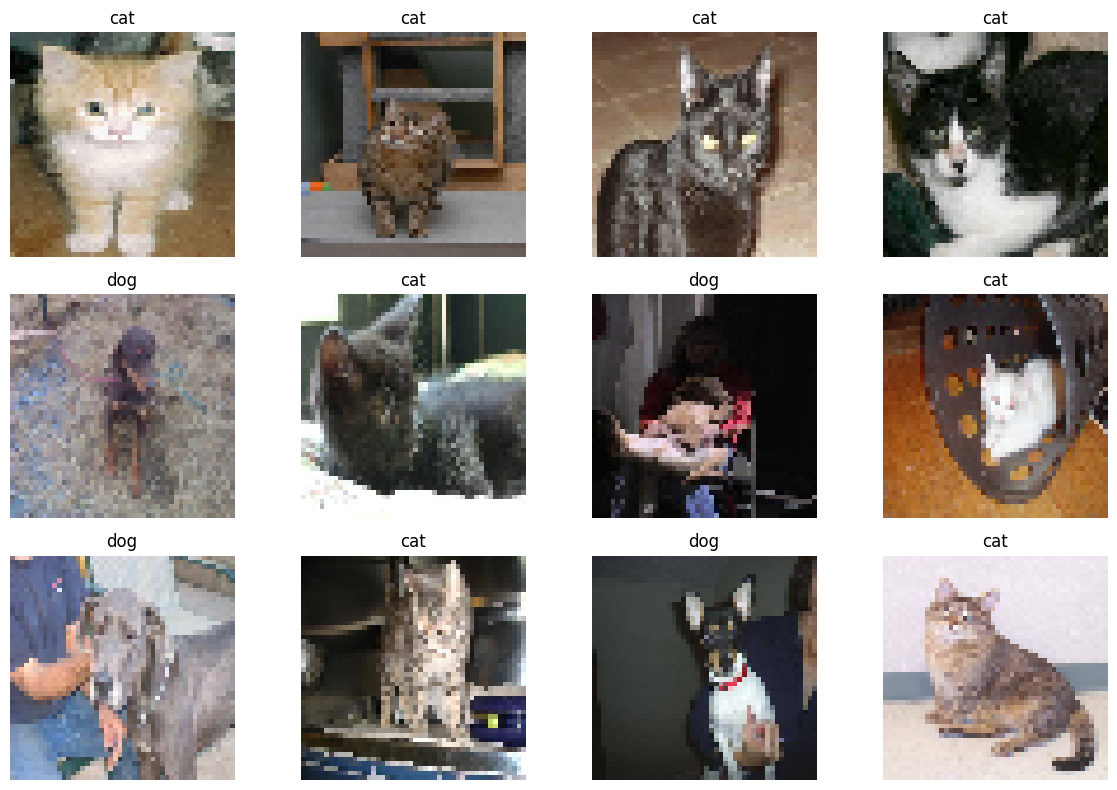

In [15]:


images, labels = next(train_plain_flow)

index_to_class = {
    value: key
    for key, value in train_flow.class_indices.items()
}

plt.figure(figsize=(12, 8))

for index in range(12):

    plt.subplot(3, 4, index + 1)
    plt.imshow(images[index])

    label_name = index_to_class[int(labels[index])]

    plt.title(label_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:


def build_cnn():

    model = models.Sequential([

        layers.Input(
            shape=(IMG_HEIGHT, IMG_WIDTH, 3)
        ),

        layers.Conv2D(
            32, (3, 3),
            padding="same",
            activation="relu"
        ),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(
            64, (3, 3),
            padding="same",
            activation="relu"
        ),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(
            128, (3, 3),
            padding="same",
            activation="relu"
        ),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),

        layers.Dense(
            128,
            activation="relu"
        ),

        layers.Dropout(0.5),

        layers.Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


model = build_cnn()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,329 (2.61 MB)

 Trainable params: 683,329 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:


fixed_model = build_cnn()

history_fixed = fixed_model.fit(
    train_flow,
    validation_data=val_flow,
    epochs=10,
    verbose=1
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 156s 246ms/step - accuracy: 0.5720 - loss: 0.6756 - val_accuracy: 0.6508 - val_loss: 0.6310
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 153s 245ms/step - accuracy: 0.6568 - loss: 0.6218 - val_accuracy: 0.6928 - val_loss: 0.5941
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 152s 243ms/step - accuracy: 0.6958 - loss: 0.5788 - val_accuracy: 0.7674 - val_loss: 0.4946
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 150s 240ms/step - accuracy: 0.7242 - loss: 0.5458 - val_accuracy: 0.7748 - val_loss: 0.4921
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 159s 254ms/step - accuracy: 0.7390 - loss: 0.5255 - val_accuracy: 0.7620 - val_loss: 0.4832
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 150s 240ms/step - accuracy: 0.7498 - loss: 0.5087 - val_accuracy: 0.7860 - val_loss: 0.4507
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 150s 239ms/step - accuracy: 0.7538 - loss: 0.4998 - val_accuracy: 0.8042 - val_loss: 0.4313
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 150s 241ms/step - accuracy: 0.7656 -

In [20]:


early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

reduce_learning_rate = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=0.000001,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "/content/best_cats_dogs_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

model = build_cnn()

history_augmented = model.fit(
    train_flow,
    validation_data=val_flow,
    epochs=30,
    callbacks=[
        early_stopping,
        reduce_learning_rate,
        checkpoint
    ],
    verbose=1
)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.5445 - loss: 0.6865
Epoch 1: val_loss improved from None to 0.61242, saving model to /content/best_cats_dogs_model.keras

Epoch 1: finished saving model to /content/best_cats_dogs_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 153s 241ms/step - accuracy: 0.5803 - loss: 0.6710 - val_accuracy: 0.6584 - val_loss: 0.6124 - learning_rate: 0.0010
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.6402 - loss: 0.6319
Epoch 2: val_loss did not improve from 0.61242
625/625 ━━━━━━━━━━━━━━━━━━━━ 151s 241ms/step - accuracy: 0.6559 - loss: 0.6189 - val_accuracy: 0.6064 - val_loss: 0.7779 - learning_rate: 0.0010
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.6851 - loss: 0.5897
Epoch 3: val_loss improved from 0.61242 to 0.52098, saving model to /content/best_cats_dogs_model.keras

Epoch 3: finished saving model to /content/best_cats_dogs_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 152s 243ms/step - accur

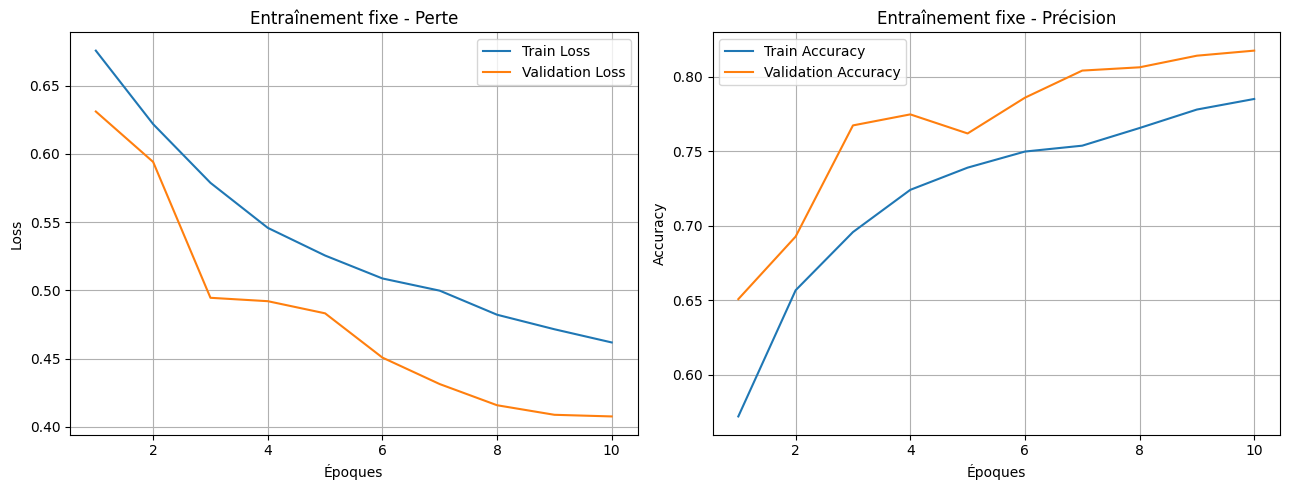

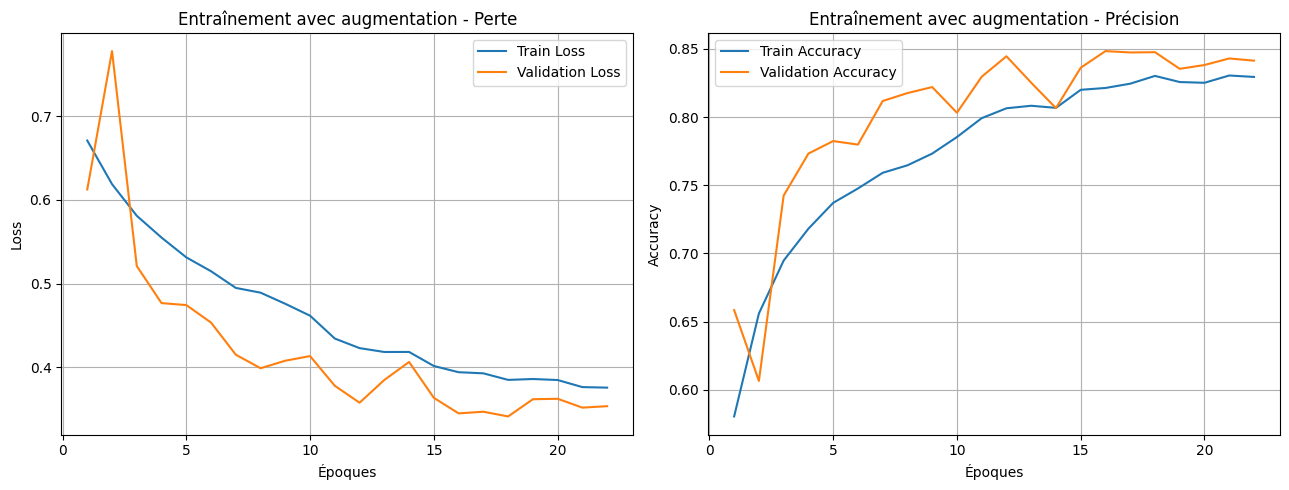

In [21]:


def plot_history(history, title):

    epochs = range(
        1,
        len(history.history["loss"]) + 1
    )

    plt.figure(figsize=(13, 5))

    plt.subplot(1, 2, 1)

    plt.plot(
        epochs,
        history.history["loss"],
        label="Train Loss"
    )

    plt.plot(
        epochs,
        history.history["val_loss"],
        label="Validation Loss"
    )

    plt.title(f"{title} - Perte")
    plt.xlabel("Époques")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)

    plt.plot(
        epochs,
        history.history["accuracy"],
        label="Train Accuracy"
    )

    plt.plot(
        epochs,
        history.history["val_accuracy"],
        label="Validation Accuracy"
    )

    plt.title(f"{title} - Précision")
    plt.xlabel("Époques")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


plot_history(
    history_fixed,
    "Entraînement fixe"
)

plot_history(
    history_augmented,
    "Entraînement avec augmentation"
)


In [22]:


val_loss, val_accuracy = model.evaluate(
    val_flow,
    verbose=1
)

print("Perte de validation :", val_loss)
print("Précision de validation :", val_accuracy)

157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 80ms/step - accuracy: 0.8476 - loss: 0.3411
Perte de validation : 0.3410907983779907
Précision de validation : 0.847599983215332


157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 80ms/step


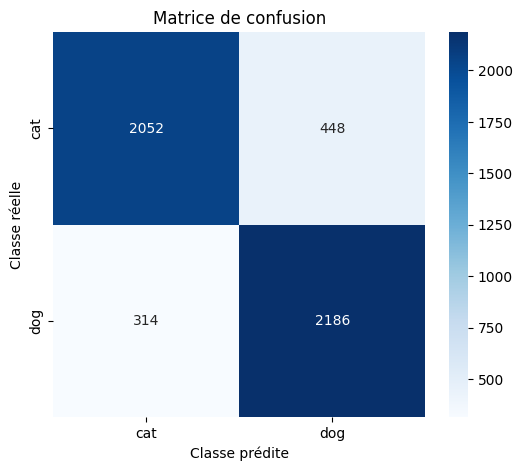

              precision    recall  f1-score   support

         cat     0.8673    0.8208    0.8434      2500
         dog     0.8299    0.8744    0.8516      2500

    accuracy                         0.8476      5000
   macro avg     0.8486    0.8476    0.8475      5000
weighted avg     0.8486    0.8476    0.8475      5000



In [23]:


val_flow.reset()

val_probabilities = model.predict(
    val_flow,
    verbose=1
).ravel()

THRESHOLD = 0.5

val_predictions = (
    val_probabilities >= THRESHOLD
).astype(int)

val_true = val_flow.classes

class_names = [
    index_to_class[index]
    for index in sorted(index_to_class)
]

matrix = confusion_matrix(
    val_true,
    val_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.title("Matrice de confusion")
plt.show()

print(
    classification_report(
        val_true,
        val_predictions,
        target_names=class_names,
        digits=4
    )
)

In [24]:


cats_predicted_as_dogs = matrix[0, 1]
dogs_predicted_as_cats = matrix[1, 0]

if cats_predicted_as_dogs > dogs_predicted_as_cats:

    print(
        "L'erreur dominante est : "
        "des chats classés comme chiens."
    )

    print(
        "On peut augmenter le seuil pour réduire "
        "les prédictions de chiens."
    )

elif dogs_predicted_as_cats > cats_predicted_as_dogs:

    print(
        "L'erreur dominante est : "
        "des chiens classés comme chats."
    )

    print(
        "On peut diminuer le seuil pour améliorer "
        "le rappel des chiens."
    )

else:
    print("Les deux types d'erreurs sont équilibrés.")

L'erreur dominante est : des chats classés comme chiens.
On peut augmenter le seuil pour réduire les prédictions de chiens.


In [25]:


test_flow.reset()

test_probabilities = model.predict(
    test_flow,
    verbose=1
).ravel()

test_predictions = (
    test_probabilities >= THRESHOLD
).astype(int)

predictions_dataframe = pd.DataFrame({

    "filepath": df_test_full["filepath"].values,

    "prob_dog": test_probabilities,

    "pred_label": [
        index_to_class[prediction]
        for prediction in test_predictions
    ]
})

display(predictions_dataframe.head())

391/391 ━━━━━━━━━━━━━━━━━━━━ 32s 80ms/step


,filepath,prob_dog,pred_label
0,/content/cats_dogs_dataset/test/test/6457.jpg,0.999620,dog
1,/content/cats_dogs_dataset/test/test/152.jpg,0.361387,cat
2,/content/cats_dogs_dataset/test/test/11684.jpg,0.169290,cat
3,/content/cats_dogs_dataset/test/test/439.jpg,0.948861,dog
4,/content/cats_dogs_dataset/test/test/5397.jpg,0.004567,cat


In [26]:


CSV_PATH = "/content/cats_dogs_predictions.csv"

predictions_dataframe.to_csv(
    CSV_PATH,
    index=False
)

print("Fichier CSV enregistré :", CSV_PATH)

Fichier CSV enregistré : /content/cats_dogs_predictions.csv


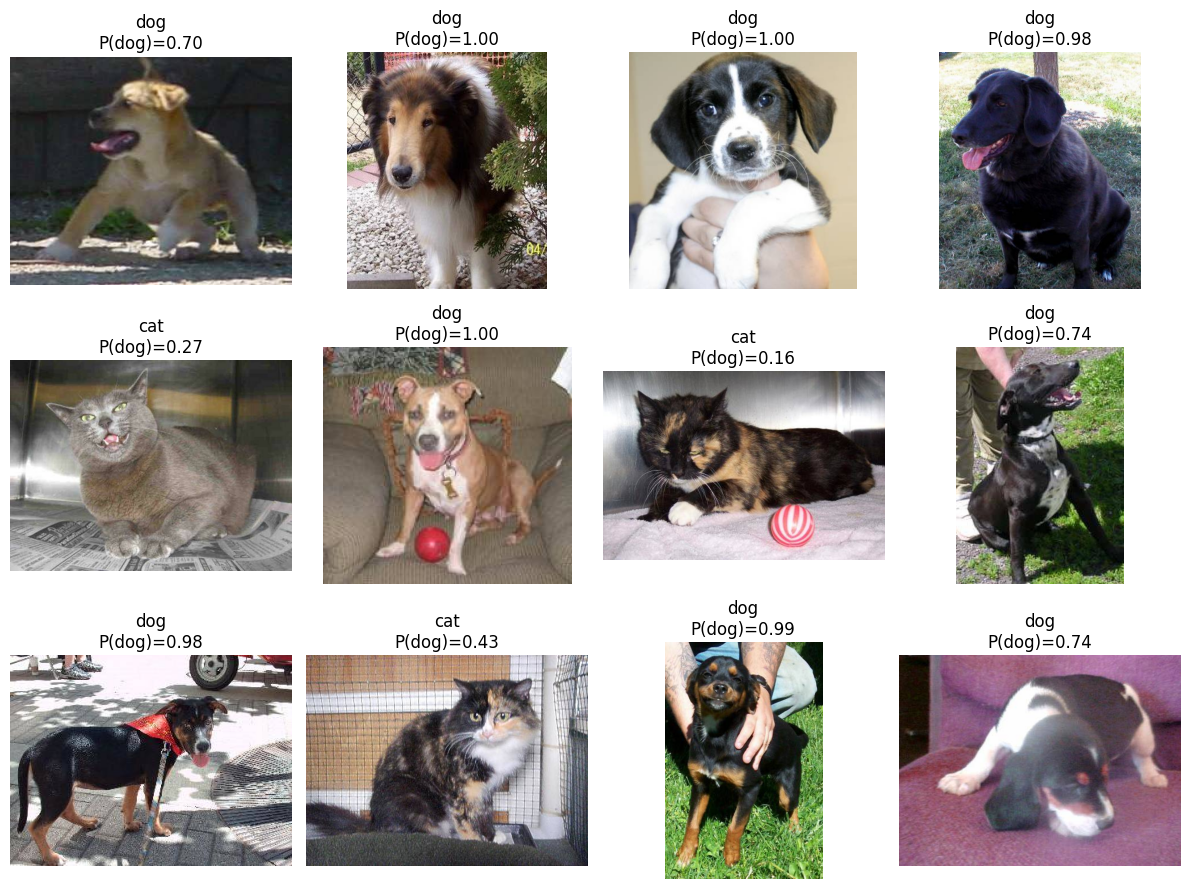

In [27]:


sample_predictions = predictions_dataframe.sample(
    n=min(12, len(predictions_dataframe)),
    random_state=SEED
)

plt.figure(figsize=(12, 9))

for index, row in enumerate(
    sample_predictions.itertuples(),
    start=1
):

    image = tf.keras.utils.load_img(
        row.filepath
    )

    plt.subplot(3, 4, index)
    plt.imshow(image)

    plt.title(
        f"{row.pred_label}\n"
        f"P(dog)={row.prob_dog:.2f}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 137s 217ms/step - accuracy: 0.6327 - loss: 0.6331 - val_accuracy: 0.7164 - val_loss: 0.5670
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 145s 231ms/step - accuracy: 0.7453 - loss: 0.5226 - val_accuracy: 0.7702 - val_loss: 0.4853
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 134s 215ms/step - accuracy: 0.7897 - loss: 0.4556 - val_accuracy: 0.7906 - val_loss: 0.4556
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 137s 219ms/step - accuracy: 0.8141 - loss: 0.4088 - val_accuracy: 0.8050 - val_loss: 0.4337
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 140s 216ms/step - accuracy: 0.8396 - loss: 0.3628 - val_accuracy: 0.8184 - val_loss: 0.3899
Restoring model weights from the end of the best epoch: 5.


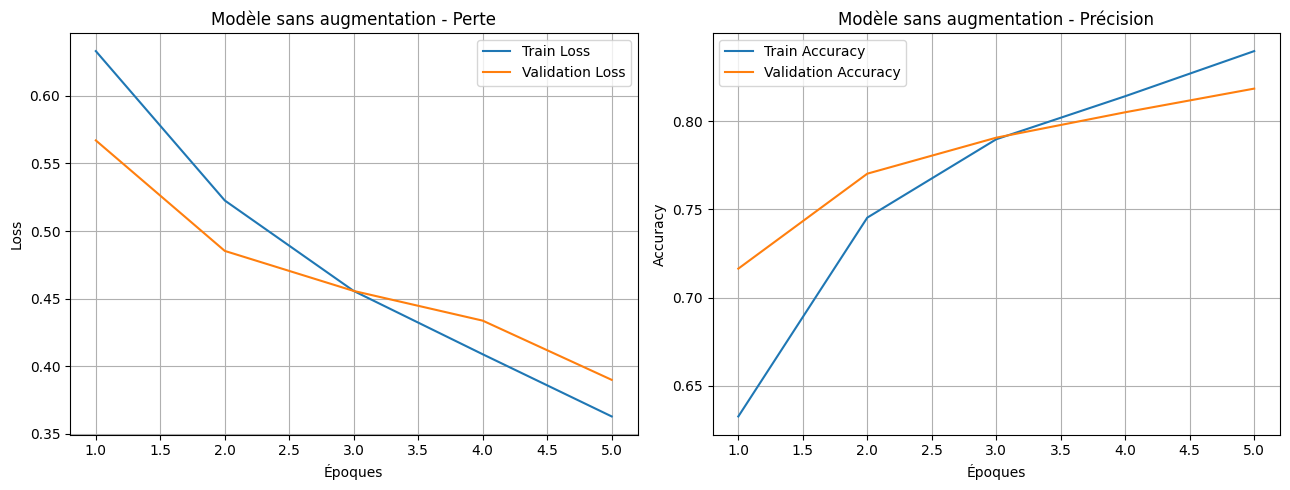

In [29]:


baseline_model = build_cnn()

baseline_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

history_baseline = baseline_model.fit(
    train_plain_flow,
    validation_data=val_flow,
    epochs=5,
    callbacks=[baseline_early_stopping],
    verbose=1
)

plot_history(
    history_baseline,
    "Modèle sans augmentation"
)

In [30]:


baseline_loss, baseline_accuracy = baseline_model.evaluate(
    val_flow,
    verbose=0
)

augmented_loss, augmented_accuracy = model.evaluate(
    val_flow,
    verbose=0
)

comparison = pd.DataFrame({

    "Modèle": [
        "Sans augmentation",
        "Avec augmentation"
    ],

    "Validation Loss": [
        baseline_loss,
        augmented_loss
    ],

    "Validation Accuracy": [
        baseline_accuracy,
        augmented_accuracy
    ]
})

display(comparison)

if augmented_accuracy > baseline_accuracy:
    print(
        "L'augmentation améliore la précision "
        "de validation."
    )
else:
    print(
        "L'augmentation n'améliore pas la précision "
        "avec cette configuration."
    )

,Modèle,Validation Loss,Validation Accuracy
0,Sans augmentation,0.389861,0.8184
1,Avec augmentation,0.341091,0.8476


L'augmentation améliore la précision de validation.


In [31]:


class_indices = train_flow.class_indices

numeric_labels = (
    df_train["label"]
    .map(class_indices)
    .to_numpy()
)

classes = np.unique(numeric_labels)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=numeric_labels
)

class_weight = dict(
    zip(classes, weights)
)

print("Poids des classes :", class_weight)

Poids des classes : {np.int64(0): np.float64(1.0), np.int64(1): np.float64(1.0)}


In [32]:


MODEL_PATH = "/content/cats_dogs_model.keras"
CONFIG_PATH = "/content/cats_dogs_config.json"

model.save(MODEL_PATH)

configuration = {
    "image_height": IMG_HEIGHT,
    "image_width": IMG_WIDTH,
    "batch_size": BATCH_SIZE,
    "seed": SEED,
    "class_indices": train_flow.class_indices,
    "threshold": THRESHOLD,
    "optimizer": "Adam",
    "learning_rate": 0.001,
    "loss": "binary_crossentropy",
    "validation_loss": float(val_loss),
    "validation_accuracy": float(val_accuracy)
}

with open(
    CONFIG_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        configuration,
        file,
        indent=4,
        ensure_ascii=False
    )

print("Modèle enregistré :", MODEL_PATH)
print("Configuration enregistrée :", CONFIG_PATH)

Modèle enregistré : /content/cats_dogs_model.keras
Configuration enregistrée : /content/cats_dogs_config.json


In [33]:


TRANSFER_HEIGHT = 96
TRANSFER_WIDTH = 96

mobile_base = tf.keras.applications.MobileNetV2(
    input_shape=(
        TRANSFER_HEIGHT,
        TRANSFER_WIDTH,
        3
    ),
    include_top=False,
    weights="imagenet"
)

mobile_base.trainable = False

transfer_model = models.Sequential([

    layers.Input(
        shape=(
            TRANSFER_HEIGHT,
            TRANSFER_WIDTH,
            3
        )
    ),

    layers.Rescaling(
        scale=2.0,
        offset=-1.0
    ),

    mobile_base,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.3),

    layers.Dense(
        1,
        activation="sigmoid"
    )
])

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)